# 🛒 E-Commerce Sales Analysis
**Tech Stack:** Python | Pandas | NumPy | Matplotlib | Seaborn  
**Dataset Source:** Kaggle — [E-Commerce Sales Dataset](https://www.kaggle.com/datasets/benroshan/ecommerce-data)

---
### 📌 Analysis Objectives
1. **Monthly Sales Trends** — Revenue & order volume over time
2. **Best-Selling Categories** — Top performers by revenue & units
3. **Customer Behavior** — Purchase patterns, retention, RFM
4. **Revenue Contribution** — Category & region-wise breakdown

### 📊 Visualizations
- Heatmaps · Line Charts · Bar Plots

## ⚙️ 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# ── Global Style ──────────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.labelcolor':  '#e0e0e0',
    'axes.titlecolor':  '#ffffff',
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'xtick.color':      '#aaaaaa',
    'ytick.color':      '#aaaaaa',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2d3040',
    'legend.facecolor': '#1a1d27',
    'legend.edgecolor': '#444',
    'font.family':      'DejaVu Sans',
})

ACCENT  = ['#00d4ff', '#ff6b6b', '#ffd166', '#06d6a0', '#a78bfa', '#f97316', '#ec4899', '#84cc16']
print('✅ Libraries loaded successfully.')

✅ Libraries loaded successfully.


## 📦 2. Load & Prepare Dataset

In [2]:
orders  = pd.read_csv('List of Orders.csv')
details = pd.read_csv('Order Details.csv')
df = orders.merge(details, on='Order ID')

# Force convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Add time columns
df['order_date'] = df['Order Date']
df['month']      = df['Order Date'].dt.month
df['month_name'] = df['Order Date'].dt.strftime('%b')
df['week']       = df['Order Date'].dt.isocalendar().week.astype(int)
df['dow']        = df['Order Date'].dt.dayofweek
df['dow_name']   = df['Order Date'].dt.strftime('%a')
df['quarter']    = df['Order Date'].dt.quarter

# Map to expected column names
df['order_id']   = df['Order ID']
df['customer_id']= df['CustomerName']
df['category']   = df['Category']
df['region']     = df['State']
df['revenue']    = df['Amount']
df['quantity']   = df['Quantity']
df['unit_price'] = df['Amount']
df['discount']   = 0.0
df['segment']    = 'Consumer'

print(f'Dataset shape : {df.shape}')
print(f'Date range    : {df.order_date.min().date()} → {df.order_date.max().date()}')
df.head()





Dataset shape : (1500, 26)
Date range    : 2018-04-01 → 2019-03-31


,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,...,quarter,order_id,customer_id,category,region,revenue,quantity,unit_price,discount,segment
0,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases,...,2,B-25601,Bharat,Furniture,Gujarat,1275.0,7,1275.0,0.0,Consumer
1,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole,...,2,B-25601,Bharat,Clothing,Gujarat,66.0,5,66.0,0.0,Consumer
2,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief,...,2,B-25601,Bharat,Clothing,Gujarat,8.0,3,8.0,0.0,Consumer
3,B-25601,2018-04-01,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games,...,2,B-25601,Bharat,Electronics,Gujarat,80.0,4,80.0,0.0,Consumer
4,B-25602,2018-04-01,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones,...,2,B-25602,Pearl,Electronics,Maharashtra,168.0,2,168.0,0.0,Consumer


In [3]:
# ── Quick EDA ─────────────────────────────────────────────────────────────────
print('=== Dataset Info ===')
print(df.info())
print('\n=== Null Values ===')
print(df.isnull().sum())
print('\n=== Basic Statistics ===')
df[['quantity','unit_price','discount','revenue']].describe().round(2)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order ID      1500 non-null   str           
 1   Order Date    1500 non-null   datetime64[us]
 2   CustomerName  1500 non-null   str           
 3   State         1500 non-null   str           
 4   City          1500 non-null   str           
 5   Amount        1500 non-null   float64       
 6   Profit        1500 non-null   float64       
 7   Quantity      1500 non-null   int64         
 8   Category      1500 non-null   str           
 9   Sub-Category  1500 non-null   str           
 10  order_date    1500 non-null   datetime64[us]
 11  month         1500 non-null   int32         
 12  month_name    1500 non-null   str           
 13  week          1500 non-null   int64         
 14  dow           1500 non-null   int32         
 15  dow_name      1500 non-null 

,quantity,unit_price,discount,revenue
count,1500.00,1500.00,1500.0,1500.00
mean,3.74,287.67,0.0,287.67
std,2.18,461.05,0.0,461.05
min,1.00,4.00,0.0,4.00
25%,2.00,45.00,0.0,45.00
50%,3.00,118.00,0.0,118.00
75%,5.00,322.00,0.0,322.00
max,14.00,5729.00,0.0,5729.00


## 📈 3. Monthly Sales Trends  _(Line Charts)_

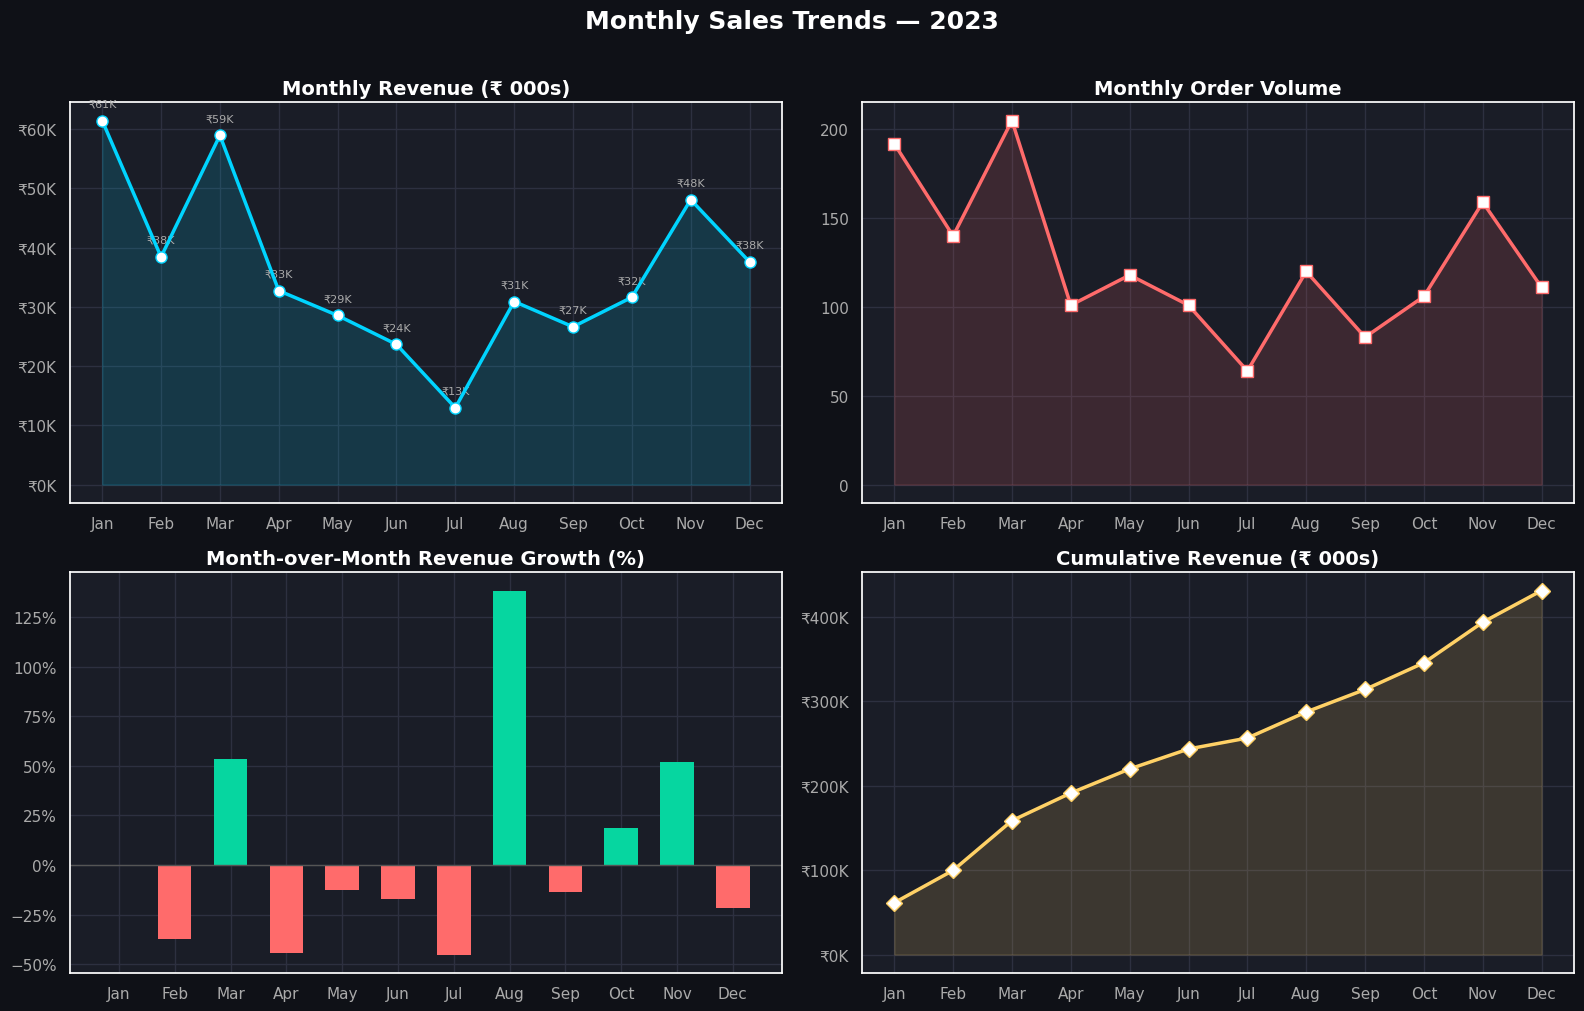

Key metrics:
  Total Revenue  : ₹431,502
  Total Orders   : 1,500
  Avg Order Value: ₹287.67
  Peak Month     : Jan (₹61,439)


In [4]:
monthly = (df.groupby(['month','month_name'])
             .agg(revenue=('revenue','sum'),
                  orders  =('order_id','count'),
                  avg_order=('revenue','mean'),
                  customers=('customer_id','nunique'))
             .reset_index()
             .sort_values('month'))

monthly['revenue_k']   = monthly['revenue'] / 1000
monthly['mom_growth']  = monthly['revenue'].pct_change() * 100
monthly['cum_revenue'] = monthly['revenue'].cumsum() / 1000

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Sales Trends — 2023', fontsize=18, fontweight='bold',
             color='white', y=1.01)
fig.patch.set_facecolor('#0f1117')

# ── Plot 1: Revenue trend ──────────────────────────────────────────────────
ax = axes[0,0]
ax.plot(monthly['month_name'], monthly['revenue_k'], marker='o', linewidth=2.5,
        color=ACCENT[0], markersize=8, markerfacecolor='white', zorder=5)
ax.fill_between(range(len(monthly)), monthly['revenue_k'], alpha=0.15, color=ACCENT[0])
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_name'])
ax.set_title('Monthly Revenue (₹ 000s)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
for i, row in monthly.iterrows():
    ax.annotate(f'₹{row.revenue_k:.0f}K', (i - monthly.index[0], row.revenue_k),
                textcoords='offset points', xytext=(0,10), ha='center', fontsize=8, color='#aaa')

# ── Plot 2: Order Volume ───────────────────────────────────────────────────
ax = axes[0,1]
ax.plot(monthly['month_name'], monthly['orders'], marker='s', linewidth=2.5,
        color=ACCENT[1], markersize=8, markerfacecolor='white', zorder=5)
ax.fill_between(range(len(monthly)), monthly['orders'], alpha=0.15, color=ACCENT[1])
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_name'])
ax.set_title('Monthly Order Volume')

# ── Plot 3: MoM Growth % ──────────────────────────────────────────────────
ax = axes[1,0]
colors_growth = [ACCENT[3] if v >= 0 else ACCENT[1] for v in monthly['mom_growth'].fillna(0)]
bars = ax.bar(monthly['month_name'], monthly['mom_growth'].fillna(0),
              color=colors_growth, edgecolor='none', width=0.6)
ax.axhline(0, color='#555', linewidth=1)
ax.set_title('Month-over-Month Revenue Growth (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

# ── Plot 4: Cumulative Revenue ────────────────────────────────────────────
ax = axes[1,1]
ax.plot(monthly['month_name'], monthly['cum_revenue'], marker='D', linewidth=2.5,
        color=ACCENT[2], markersize=8, markerfacecolor='white', zorder=5)
ax.fill_between(range(len(monthly)), monthly['cum_revenue'], alpha=0.15, color=ACCENT[2])
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['month_name'])
ax.set_title('Cumulative Revenue (₹ 000s)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))

plt.tight_layout()
plt.savefig('monthly_sales_trends.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Key metrics:')
print(f'  Total Revenue  : ₹{df.revenue.sum():,.0f}')
print(f'  Total Orders   : {len(df):,}')
print(f'  Avg Order Value: ₹{df.revenue.mean():,.2f}')
print(f'  Peak Month     : {monthly.loc[monthly.revenue.idxmax(), "month_name"]} (₹{monthly.revenue.max():,.0f})')

## 🏆 4. Best-Selling Categories  _(Bar Plots)_

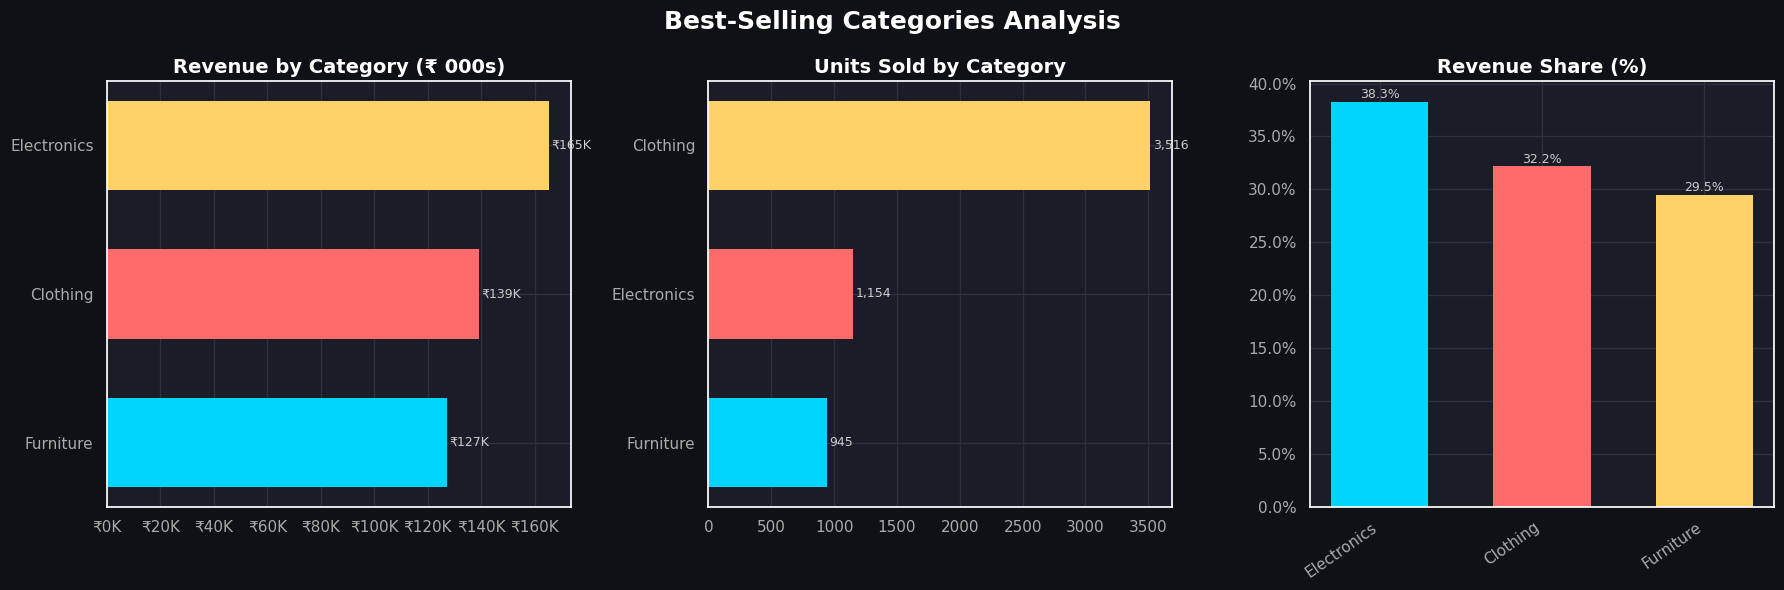

   category  revenue  units  revenue_share
Electronics 165267.0   1154           38.3
   Clothing 139054.0   3516           32.2
  Furniture 127181.0    945           29.5


In [5]:
cat_stats = (df.groupby('category')
               .agg(revenue=('revenue','sum'),
                    orders  =('order_id','count'),
                    units   =('quantity','sum'),
                    avg_price=('unit_price','mean'),
                    avg_discount=('discount','mean'))
               .reset_index()
               .sort_values('revenue', ascending=False))

cat_stats['revenue_share'] = (cat_stats['revenue'] / cat_stats['revenue'].sum() * 100).round(1)
cat_stats['revenue_k']     = cat_stats['revenue'] / 1000

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Best-Selling Categories Analysis', fontsize=18, fontweight='bold', color='white')
fig.patch.set_facecolor('#0f1117')

# ── Plot 1: Revenue by Category ───────────────────────────────────────────
ax = axes[0]
sorted_cat = cat_stats.sort_values('revenue')
bars = ax.barh(sorted_cat['category'], sorted_cat['revenue_k'],
               color=ACCENT[:len(cat_stats)], edgecolor='none', height=0.6)
ax.set_title('Revenue by Category (₹ 000s)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
for bar, val in zip(bars, sorted_cat['revenue_k']):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'₹{val:.0f}K', va='center', fontsize=9, color='#ccc')

# ── Plot 2: Units Sold ────────────────────────────────────────────────────
ax = axes[1]
sorted_units = cat_stats.sort_values('units')
bars = ax.barh(sorted_units['category'], sorted_units['units'],
               color=ACCENT[:len(cat_stats)], edgecolor='none', height=0.6)
ax.set_title('Units Sold by Category')
for bar, val in zip(bars, sorted_units['units']):
    ax.text(val + 20, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9, color='#ccc')

# ── Plot 3: Revenue Share Donut-style Bar ─────────────────────────────────
ax = axes[2]
cat_rev = cat_stats.sort_values('revenue', ascending=False)
bars = ax.bar(cat_rev['category'], cat_rev['revenue_share'],
              color=ACCENT[:len(cat_stats)], edgecolor='none', width=0.6)
ax.set_title('Revenue Share (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticklabels(cat_rev['category'], rotation=35, ha='right')
for bar, val in zip(bars, cat_rev['revenue_share']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val}%', ha='center', fontsize=9, color='#ccc')

plt.tight_layout()
plt.savefig('best_selling_categories.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print(cat_stats[['category','revenue','units','revenue_share']].to_string(index=False))

## 🌡️ 5. Sales Heatmaps — Time & Category Patterns

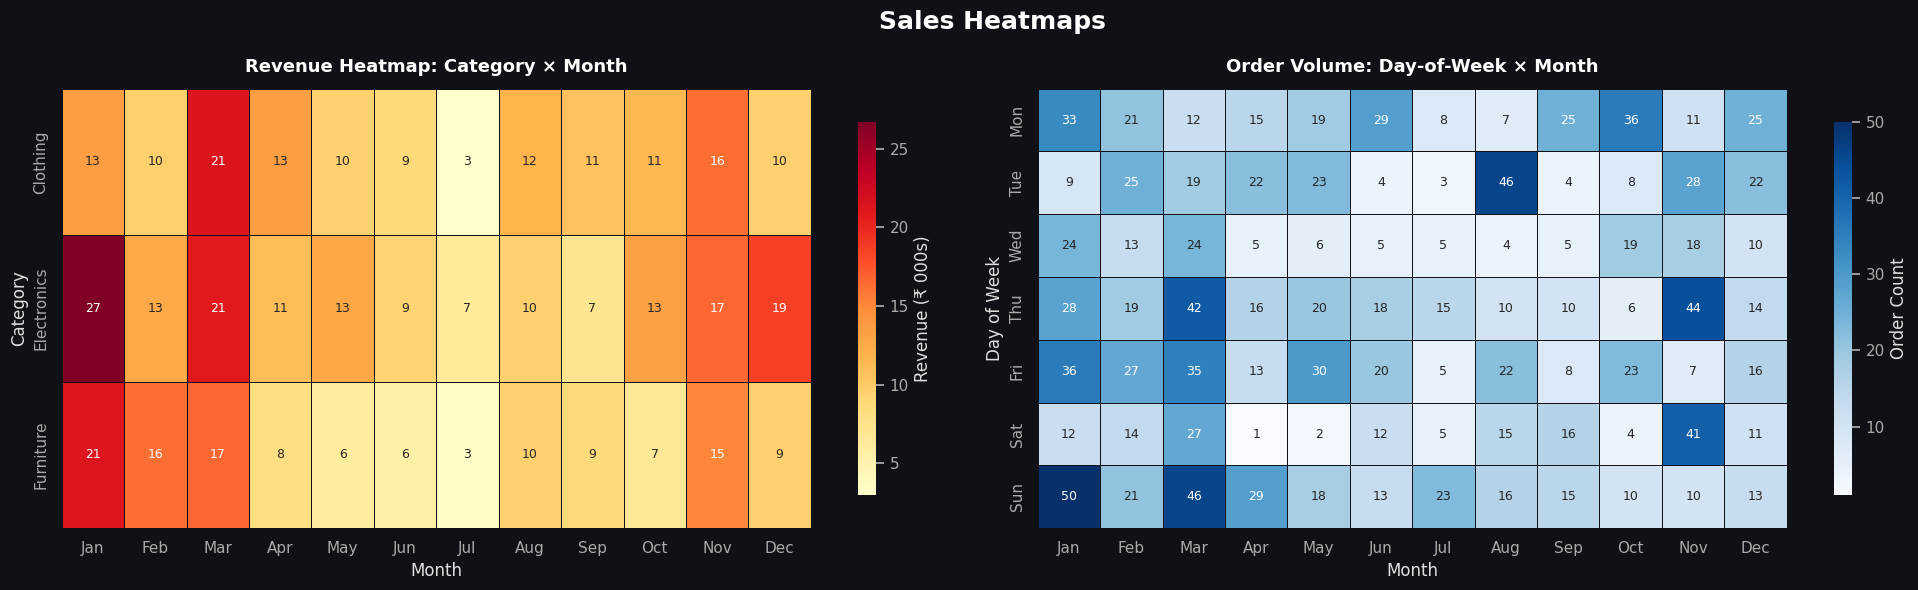

In [6]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
# ── Heatmap 1: Revenue by Month × Category ────────────────────────────────
pivot_cat_month = df.pivot_table(
    values='revenue', index='category', columns='month', aggfunc='sum'
).fillna(0)
pivot_cat_month.columns = months[:len(pivot_cat_month.columns)]

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle('Sales Heatmaps', fontsize=18, fontweight='bold', color='white')
fig.patch.set_facecolor('#0f1117')

ax = axes[0]
sns.heatmap(
    pivot_cat_month / 1000,
    ax=ax, cmap='YlOrRd', annot=True, fmt='.0f',
    linewidths=0.4, linecolor='#0f1117',
    cbar_kws={'label': 'Revenue (₹ 000s)', 'shrink': 0.85},
    annot_kws={'size': 9}
)
ax.set_title('Revenue Heatmap: Category × Month', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Category')

# ── Heatmap 2: Orders by Day-of-Week × Month ─────────────────────────────
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot_dow_month = df.pivot_table(
    values='order_id', index='dow_name', columns='month', aggfunc='count'
).reindex(day_order).fillna(0)
pivot_dow_month.columns = months[:len(pivot_dow_month.columns)]

ax = axes[1]
sns.heatmap(
    pivot_dow_month,
    ax=ax, cmap='Blues', annot=True, fmt='.0f',
    linewidths=0.4, linecolor='#0f1117',
    cbar_kws={'label': 'Order Count', 'shrink': 0.85},
    annot_kws={'size': 9}
)
ax.set_title('Order Volume: Day-of-Week × Month', fontsize=13, pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Day of Week')

plt.tight_layout()
plt.savefig('sales_heatmaps.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

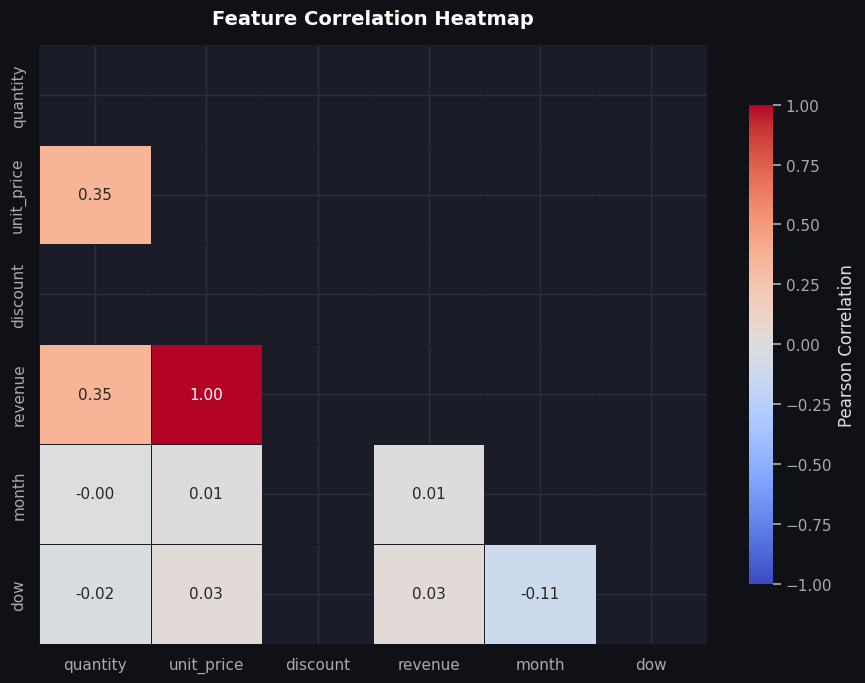

In [7]:
# ── Heatmap 3: Discount vs Revenue Correlation Matrix ────────────────────
corr_cols = ['quantity','unit_price','discount','revenue','month','dow']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
fig.patch.set_facecolor('#0f1117')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, ax=ax, mask=mask,
    cmap='coolwarm', vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 11},
    linewidths=0.5, linecolor='#1a1d27',
    cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 👤 6. Customer Behavior Analysis

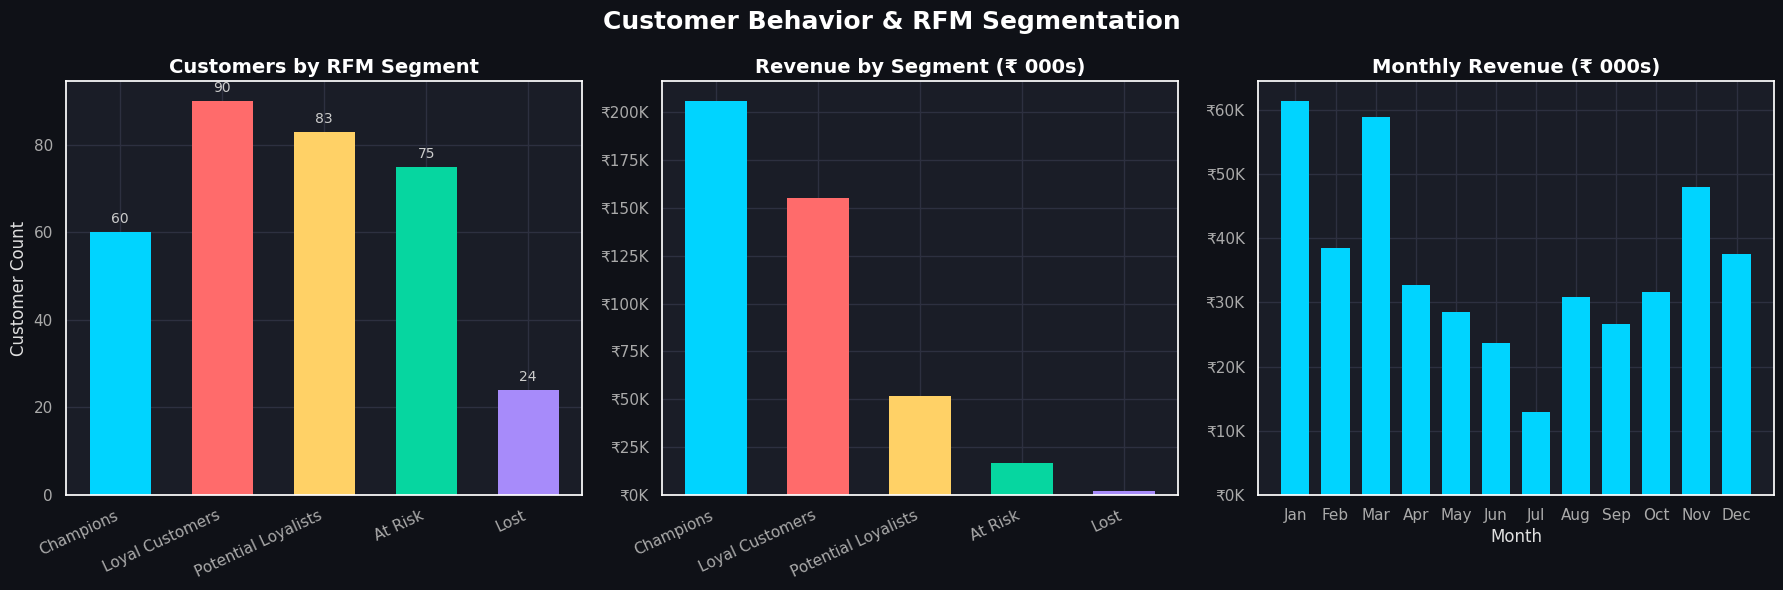


=== RFM Segment Summary ===
                     recency  frequency  monetary
segment                                          
At Risk                178.1        1.5     222.2
Champions               36.7       10.6    3433.0
Lost                   242.0        1.0      82.0
Loyal Customers        111.0        5.5    1723.5
Potential Loyalists    144.6        2.9     623.8


In [8]:
# ── RFM Analysis ──────────────────────────────────────────────────────────
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    recency  =('order_date',   lambda x: (snapshot_date - x.max()).days),
    frequency=('order_id',     'count'),
    monetary =('revenue',      'sum')
).reset_index()

# Score each dimension 1-5
rfm['R_score'] = pd.qcut(rfm['recency'],   5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'],  5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_total'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

def segment(score):
    if score >= 13: return 'Champions'
    elif score >= 10: return 'Loyal Customers'
    elif score >= 7:  return 'Potential Loyalists'
    elif score >= 5:  return 'At Risk'
    else: return 'Lost'

rfm['segment'] = rfm['RFM_total'].apply(segment)

seg_order  = ['Champions','Loyal Customers','Potential Loyalists','At Risk','Lost']
seg_counts = rfm['segment'].value_counts().reindex(seg_order)
seg_revenue = rfm.groupby('segment')['monetary'].sum().reindex(seg_order)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Customer Behavior & RFM Segmentation', fontsize=18, fontweight='bold', color='white')
fig.patch.set_facecolor('#0f1117')

# Plot 1: Customer segment bar
ax = axes[0]
bars = ax.bar(seg_counts.index, seg_counts.values, color=ACCENT[:5], edgecolor='none', width=0.6)
ax.set_title('Customers by RFM Segment')
ax.set_xticklabels(seg_counts.index, rotation=25, ha='right')
ax.set_ylabel('Customer Count')
for bar, val in zip(bars, seg_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', fontsize=10, color='#ccc')

# Plot 2: Revenue by segment
ax = axes[1]
bars = ax.bar(seg_revenue.index, seg_revenue.values / 1000, color=ACCENT[:5], edgecolor='none', width=0.6)
ax.set_title('Revenue by Segment (₹ 000s)')
ax.set_xticklabels(seg_revenue.index, rotation=25, ha='right')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))


# Plot 3: Monthly revenue bar
ax = axes[2]
monthly_rev = df.groupby('month')['revenue'].sum() / 1000
ax.bar(range(1, len(monthly_rev)+1), monthly_rev.values, color=ACCENT[0], edgecolor='none', width=0.7)
ax.set_title('Monthly Revenue (₹ 000s)')
ax.set_xlabel('Month')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
ax.set_xticks(range(1, len(monthly_rev)+1))
ax.set_xticklabels(months[:len(monthly_rev)])

plt.tight_layout()
plt.savefig('customer_behavior.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print('\n=== RFM Segment Summary ===')
print(rfm.groupby('segment')[['recency','frequency','monetary']].mean().round(1))

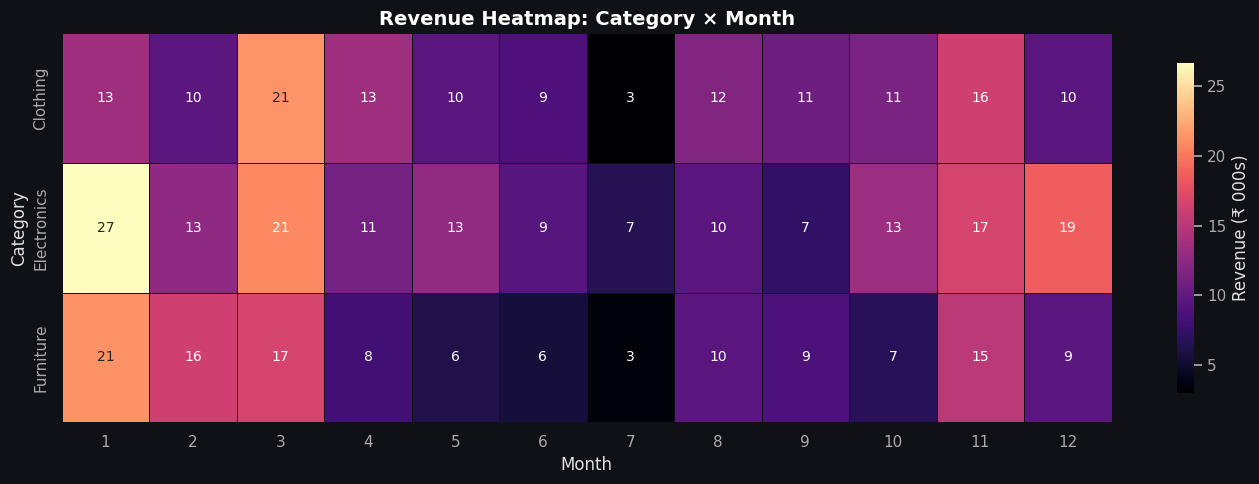

In [9]:
# ── Customer Purchase Behavior: Segment × Category Heatmap ───────────────
seg_cat_pivot = df.pivot_table(
    values='revenue', index='category', columns='month', aggfunc='sum'
).fillna(0) / 1000

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#0f1117')
sns.heatmap(
    seg_cat_pivot, ax=ax, cmap='magma', annot=True, fmt='.0f',
    linewidths=0.4, linecolor='#0f1117',
    cbar_kws={'label': 'Revenue (₹ 000s)', 'shrink': 0.85},
    annot_kws={'size': 10}
)
ax.set_title('Revenue Heatmap: Category × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig('segment_category_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 💰 7. Revenue Contribution Analysis  _(Bar Plots & Line Charts)_

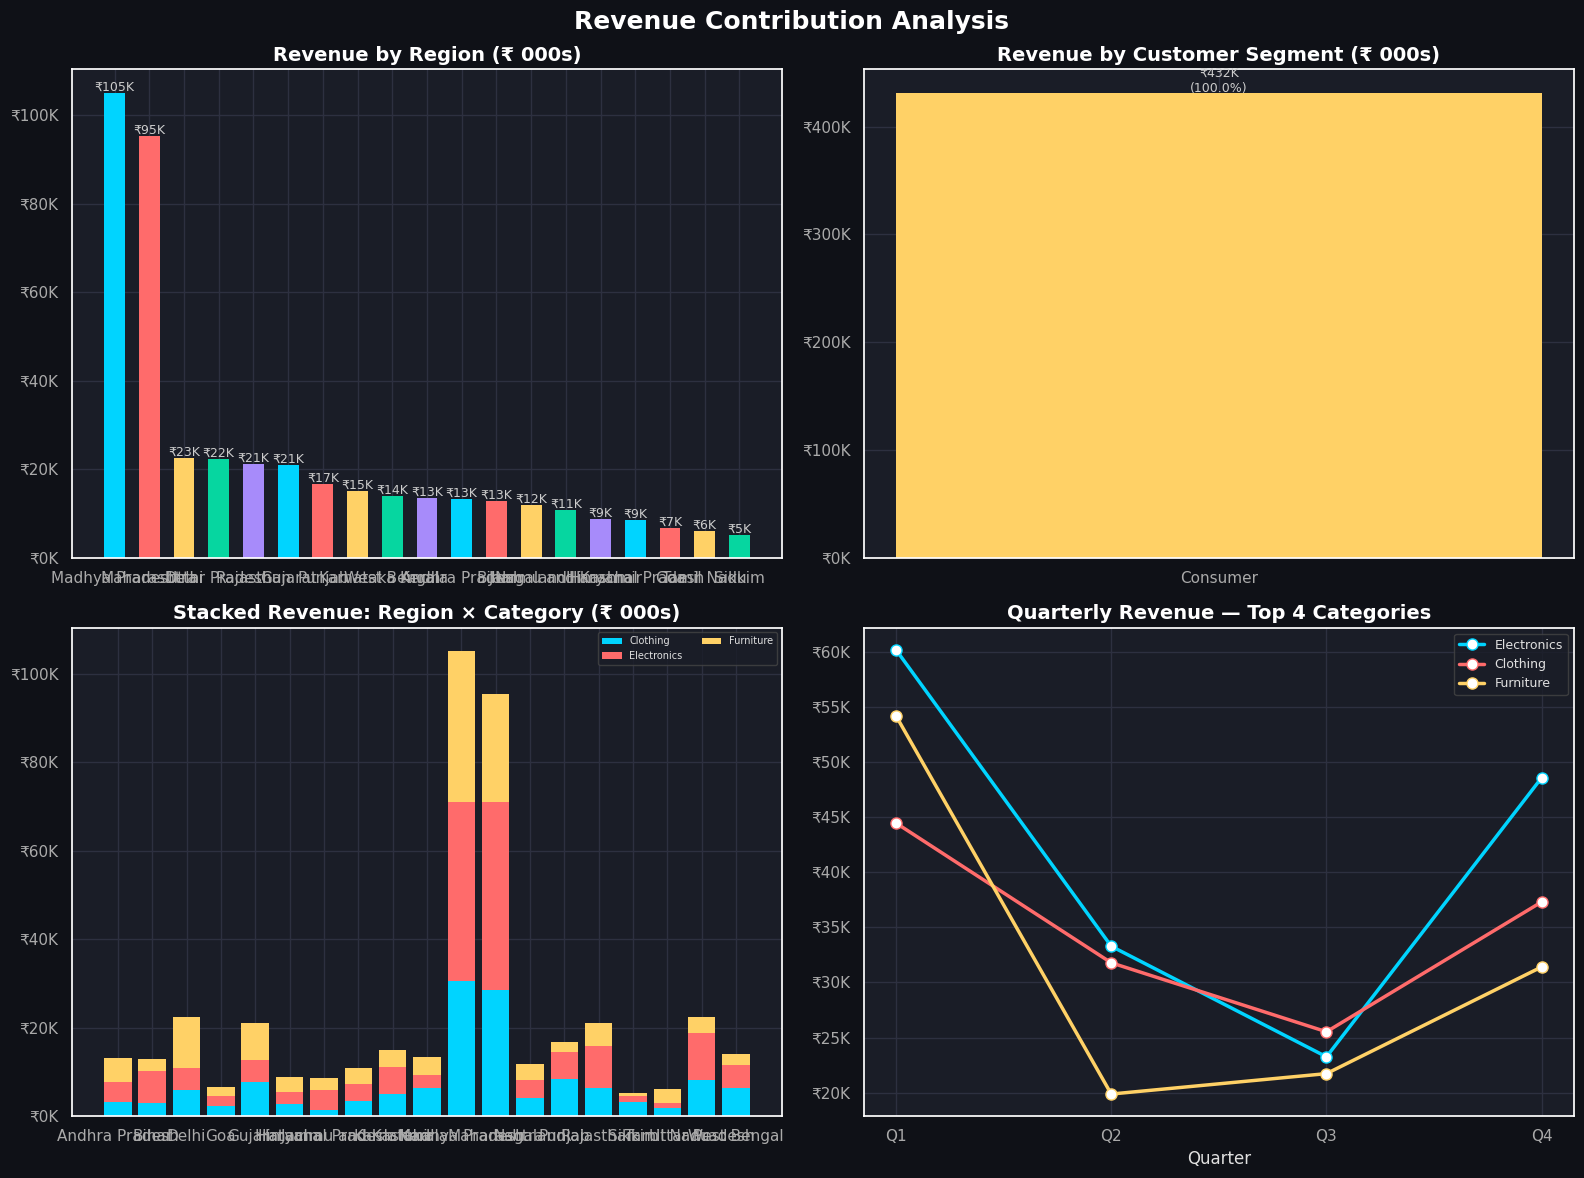

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Revenue Contribution Analysis', fontsize=18, fontweight='bold', color='white')
fig.patch.set_facecolor('#0f1117')

# ── Plot 1: Revenue by Region ─────────────────────────────────────────────
ax = axes[0,0]
region_rev = df.groupby('region')['revenue'].sum().sort_values(ascending=False)
bars = ax.bar(region_rev.index, region_rev.values / 1000, color=ACCENT[:5], edgecolor='none', width=0.6)
ax.set_title('Revenue by Region (₹ 000s)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
for bar, val in zip(bars, region_rev.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'₹{val/1000:.0f}K', ha='center', fontsize=9, color='#ccc')

# ── Plot 2: Revenue by Customer Segment ──────────────────────────────────
ax = axes[0,1]
seg_rev = df.groupby('segment')['revenue'].sum().sort_values(ascending=False)
bars = ax.bar(seg_rev.index, seg_rev.values / 1000, color=ACCENT[2:5], edgecolor='none', width=0.6)
ax.set_title('Revenue by Customer Segment (₹ 000s)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
for bar, val in zip(bars, seg_rev.values):
    pct = val / seg_rev.sum() * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'₹{val/1000:.0f}K\n({pct:.1f}%)', ha='center', fontsize=9, color='#ccc')

# ── Plot 3: Stacked Region × Category Revenue ────────────────────────────
ax = axes[1,0]
reg_cat = df.pivot_table(values='revenue', index='region', columns='category', aggfunc='sum').fillna(0) / 1000
bottom = np.zeros(len(reg_cat))
for i, cat in enumerate(reg_cat.columns):
    ax.bar(reg_cat.index, reg_cat[cat].values, bottom=bottom, label=cat, color=ACCENT[i % len(ACCENT)], edgecolor='none')
    bottom += reg_cat[cat].values
ax.set_title('Stacked Revenue: Region × Category (₹ 000s)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
ax.legend(loc='upper right', fontsize=7, ncol=2)

# ── Plot 4: Quarterly Revenue Trend by Category ───────────────────────────
ax = axes[1,1]
top4_cats = cat_stats.head(4)['category'].tolist()
q_cat = df[df['category'].isin(top4_cats)].pivot_table(
    values='revenue', index='quarter', columns='category', aggfunc='sum'
).fillna(0) / 1000
for i, cat in enumerate(top4_cats):
    if cat in q_cat.columns:
        ax.plot(q_cat.index, q_cat[cat], marker='o', linewidth=2.5, label=cat,
                color=ACCENT[i], markersize=8, markerfacecolor='white')
ax.set_title('Quarterly Revenue — Top 4 Categories')
ax.set_xlabel('Quarter')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'₹{x:.0f}K'))
ax.set_xticks([1,2,3,4])
ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('revenue_contribution.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

## 📋 8. Executive Summary

In [11]:
total_rev   = df['revenue'].sum()
total_orders= len(df)
aov         = df['revenue'].mean()
top_cat     = cat_stats.iloc[0]
top_region  = df.groupby('region')['revenue'].sum().idxmax()
best_month  = monthly.loc[monthly['revenue'].idxmax(), 'month_name']
champions   = rfm[rfm['segment'] == 'Champions']

print('=' * 55)
print('        📊 E-COMMERCE ANALYSIS — EXECUTIVE SUMMARY')
print('=' * 55)
print(f'  Total Revenue       : ₹{total_rev:>12,.0f}')
print(f'  Total Orders        : {total_orders:>12,}')
print(f'  Avg Order Value     : ₹{aov:>12,.2f}')
print(f'  Unique Customers    : {df.customer_id.nunique():>12,}')
print('-' * 55)
print(f'  🏆 Top Category     : {top_cat["category"]} ({top_cat["revenue_share"]}% share)')
print(f'  🌍 Top Region       : {top_region}')
print(f'  📅 Best Month       : {best_month}')
print(f'  👑 Champion Cust.   : {len(champions)} ({len(champions)/len(rfm)*100:.1f}% of base)')
print(f'  💸 Champion Revenue : ₹{champions["monetary"].sum():,.0f}')
print('=' * 55)
print('\n✅ Charts saved:')
for f in ['monthly_sales_trends.png','best_selling_categories.png',
          'sales_heatmaps.png','correlation_heatmap.png',
          'customer_behavior.png','segment_category_heatmap.png',
          'revenue_contribution.png']:
    print(f'   📁 {f}')

        📊 E-COMMERCE ANALYSIS — EXECUTIVE SUMMARY
  Total Revenue       : ₹     431,502
  Total Orders        :        1,500
  Avg Order Value     : ₹      287.67
  Unique Customers    :          332
-------------------------------------------------------
  🏆 Top Category     : Electronics (38.3% share)
  🌍 Top Region       : Madhya Pradesh
  📅 Best Month       : Jan
  👑 Champion Cust.   : 60 (18.1% of base)
  💸 Champion Revenue : ₹205,979

✅ Charts saved:
   📁 monthly_sales_trends.png
   📁 best_selling_categories.png
   📁 sales_heatmaps.png
   📁 correlation_heatmap.png
   📁 customer_behavior.png
   📁 segment_category_heatmap.png
   📁 revenue_contribution.png
